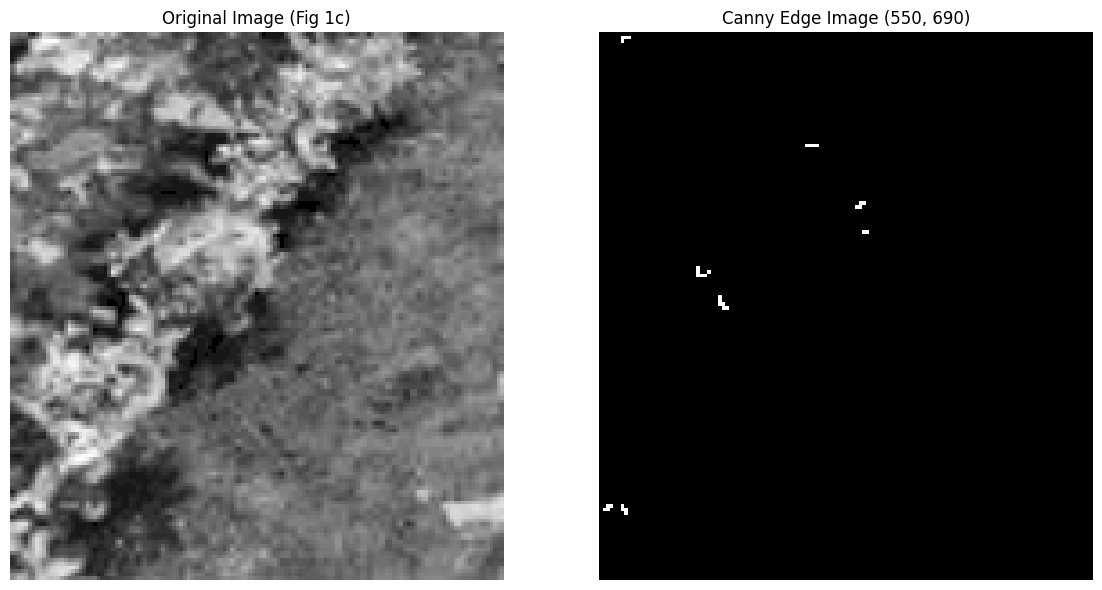

Extracted 34 edge points for further analysis.


In [2]:
# --- Question 1: Edge Detection Using Canny ---
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image 
img = cv.imread('crop_field.png', cv.IMREAD_GRAYSCALE)

# 2. Apply Canny Edge Detector with specific thresholds
# minVal = 550, maxVal = 690 as per instructions
edges = cv.Canny(img, 550, 690) 

# 3. Plot the original and edge image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image (Fig 1c)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Image (550, 690)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Extract feature positions (x, y coordinates)
# np.where returns (rows, cols) -> (y, x)
indices = np.where(edges != 0) 
y = indices[0] 
x = indices[1] 

print(f"Extracted {len(x)} edge points for further analysis.")

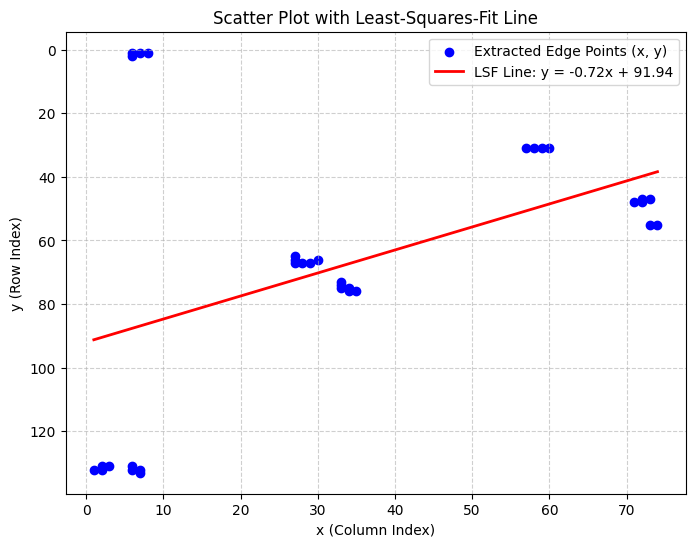

Least-Squares Slope (m): -0.7235
Least-Squares Intercept (c): 91.9364


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Question 2: Scatter Plot ---
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Extracted Edge Points (x, y)')

# --- Question 3: Least-Squares-Fit (LSF) ---
# Use np.polyfit for a first-degree (linear) fit: y = mx + c
# Note: LSF minimizes the vertical (y) residuals
slope_lsf, intercept_lsf = np.polyfit(x, y, 1)

# Generate points for the fitted line
x_fit = np.array([min(x), max(x)])
y_fit_lsf = slope_lsf * x_fit + intercept_lsf

# Plotting the LSF line
plt.plot(x_fit, y_fit_lsf, color='red', linewidth=2, label=f'LSF Line: y = {slope_lsf:.2f}x + {intercept_lsf:.2f}')

# Formatting the plot
plt.title('Scatter Plot with Least-Squares-Fit Line')
plt.xlabel('x (Column Index)')
plt.ylabel('y (Row Index)')
plt.gca().invert_yaxis() 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Least-Squares Slope (m): {slope_lsf:.4f}")
print(f"Least-Squares Intercept (c): {intercept_lsf:.4f}")

In [4]:
import math

# Question 4: Calculate the angle theta in degrees
# slope_lsf was calculated as -0.72 in the previous step
theta_rad = math.atan(slope_lsf)
theta_deg = math.degrees(theta_rad)

# Conventionally, we take the absolute value or adjust based on the image quadrant
estimated_theta = abs(theta_deg)

print(f"Estimated Crop Field Angle (theta): {estimated_theta:.2f} degrees")

Estimated Crop Field Angle (theta): 35.89 degrees
